<a href="https://colab.research.google.com/github/afifamaisha13/Machine_learing-and-Deep_learning/blob/main/SHAP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [75]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import seaborn as sns
import shap
import pandas as pd
from sklearn.preprocessing import LabelEncoder

In [ ]:
df= sns.load_dataset('iris')

In [ ]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [ ]:
X= df.drop('species',axis=1)
y=df['species']

In [ ]:
le=LabelEncoder()
y_encoded=le.fit_transform(y)

In [ ]:
#test_size determines the proportion of data allocated for model training versus evaluation
#An 0.33 split reserves 33% of your data for testing and 67% for training, whereas a 0.2 split uses 20% for testing and 80% for training
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.33, random_state=42,stratify= y_encoded)

#Logistic regression

In [ ]:
log_model= LogisticRegression(
    penalty='l2',
    C=1.0,
    solver='liblinear',
    max_iter=100,
    random_state=42
)

In [ ]:
rf_model= RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    random_state=42
)

In [ ]:
log_model.fit(X_train,y_train)

LogisticRegression(random_state=42, solver='liblinear')

In [ ]:
y_pred=log_model.predict(X_test)

In [ ]:
accuracy=accuracy_score(y_test,y_pred)

In [ ]:
accuracy

0.92

#SHAP for explaining the prediction

In [ ]:
explainer = shap.LinearExplainer(log_model, X_train)

In [ ]:
shap_values = explainer.shap_values(X_test)

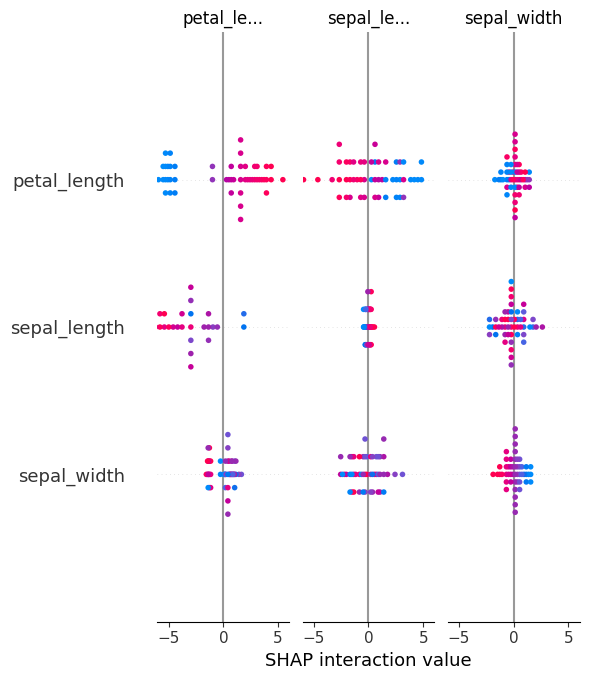

In [ ]:
#SHAP Summary Plot (Most Important)
shap.summary_plot(
    shap_values,
    X_test
)

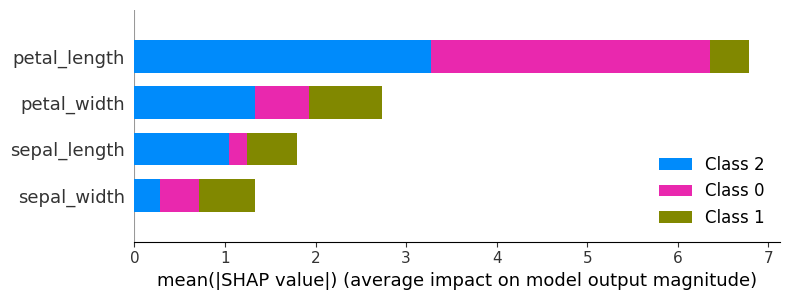

In [ ]:
#SHAP Bar Plot
shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar"
)

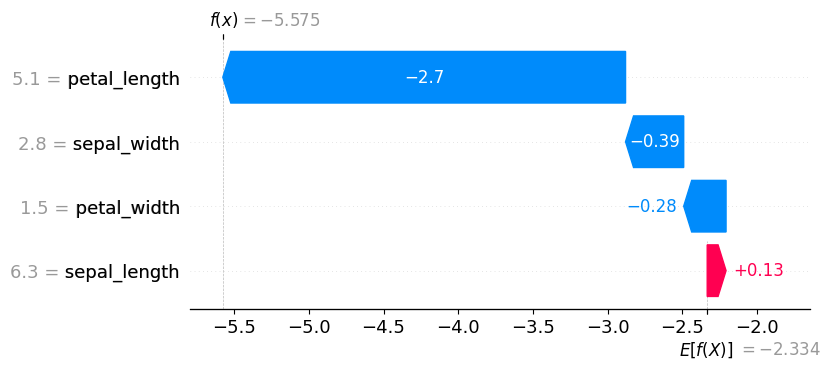

In [ ]:
#Waterfall plot: explain one prediction
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[:,:,0][0],
        base_values=explainer.expected_value[0],
        data=X_test.iloc[0],
        feature_names=X_test.columns
    )
)

In [ ]:
#Force Plot
shap.initjs()

shap.force_plot(
    explainer.expected_value[0],
    shap_values[:,:,0][0],
    X_test.iloc[0]
)

#Perforn random forest

In [76]:
rf_model= RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    random_state=42
)

In [77]:
rf_model.fit(X_train,y_train)

RandomForestClassifier(random_state=42)

In [78]:
y_pred=rf_model.predict(X_test)

In [79]:
accuracy=accuracy_score(y_test,y_pred)

In [73]:
accuracy

0.9

#Use of SHAP

In [80]:
explainer = shap.TreeExplainer(rf_model)

In [81]:
shap_values = explainer.shap_values(X_test)

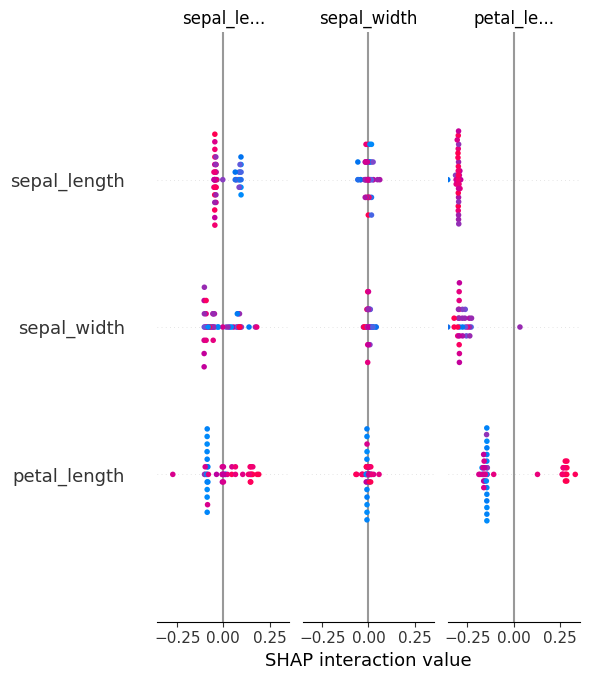

In [82]:
shap.summary_plot(
    shap_values,
    X_test
)

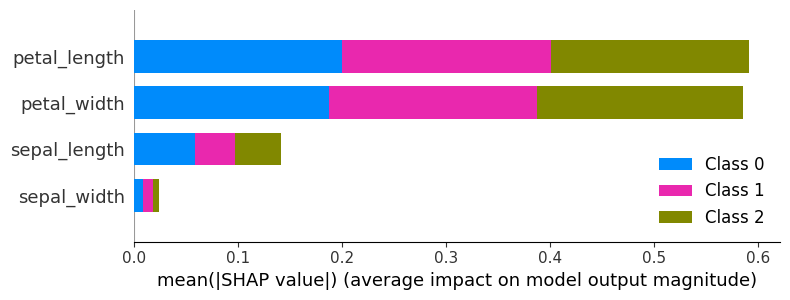

In [83]:
shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar"
)

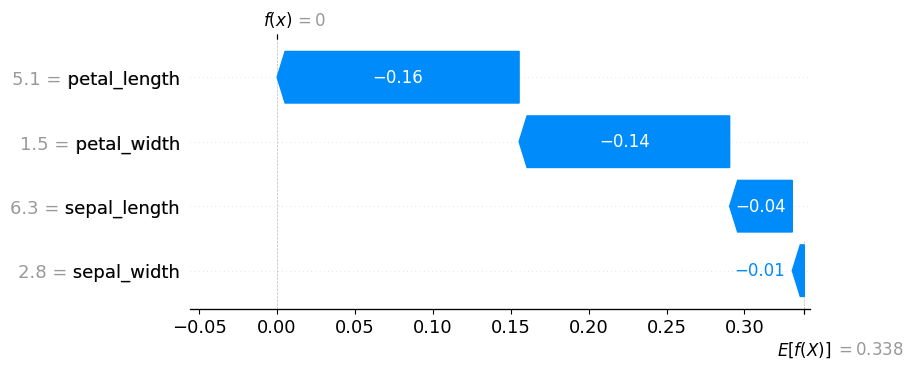

In [85]:
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[:,:,0][0],
        base_values=explainer.expected_value[0],
        data=X_test.iloc[0],
        feature_names=X_test.columns
    )
)

In [86]:
shap.initjs()

shap.force_plot(
    explainer.expected_value[0],
    shap_values[:,:,0][0],
    X_test.iloc[0]
)